In [2]:
# Import necessary libs
import pandas as pd
import os
import matplotlib.pyplot as plt

from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# Load cleaned data
path = ("../data/processed/")

files = sorted([f for f in os.listdir(path) if f.endswith(".parquet")])

dfs = [pd.read_parquet(os.path.join(path, f)) for f in files]

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(3396556, 7)


In [4]:
# Extract Ethiopia Dataset
ethiopia_df = df[
    df["RecipientName"].str.contains("Ethiopia", case=False, na=False)
].copy()

print(ethiopia_df.shape)

(53372, 7)


In [5]:
# Prepare data 
trend = ethiopia_df.groupby("Year")["USD_Commitment"].sum().reset_index()

In [7]:
# ---- Risk Scoring ----

# 1. Donor Dependency Risk
dependency_ratio = 0.7116363172872341
donor_dependency = dependency_ratio  # already computed (~0.71)
risk_donor = donor_dependency * 100

# 2. Climate Alignment Risk
ratio = 0.6874046039438971
climate_share = ratio  # adaptation/(adaptation+mitigation) is NOT full climate share
# better: use computed climate-targeted finance share
climate_targeted_share = 0.12821674714248557  # Actual value

risk_alignment = (1 - climate_targeted_share) * 100

# 3. Volatility Risk
volatility = 0.20906019169720838
risk_volatility = volatility * 100

# 4. Sector Concentration Risk
sector_concentration = 0.24412960195897318  # highest sector dominance is emergency response
risk_sector = sector_concentration * 100

# Combine into DataFrame
risk_df = pd.DataFrame({
    "Risk Type": [
        "Donor Dependency",
        "Climate Alignment",
        "Volatility",
        "Sector Concentration"
    ],
    "Risk Score (0-100)": [
        risk_donor,
        risk_alignment,
        risk_volatility,
        risk_sector
    ]
})

risk_df

,Risk Type,Risk Score (0-100)
0,Donor Dependency,71.163632
1,Climate Alignment,87.178325
2,Volatility,20.906019
3,Sector Concentration,24.412960


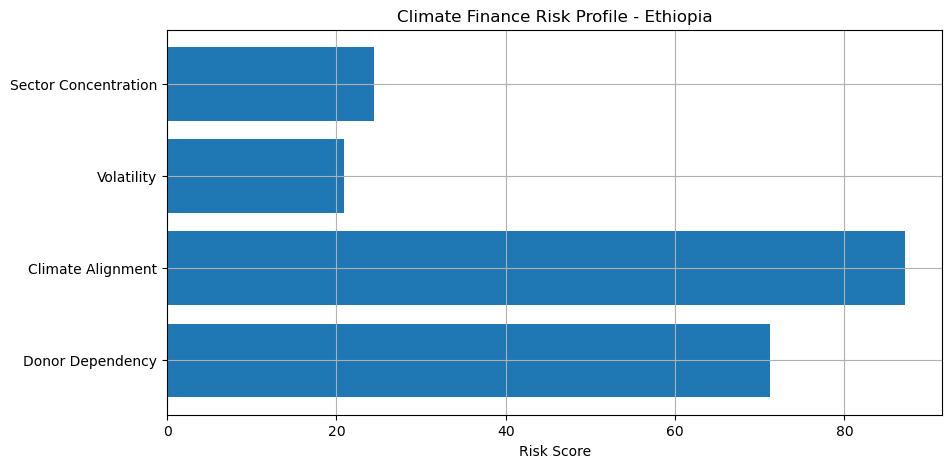

In [9]:
plt.figure(figsize=(10, 5))
plt.barh(risk_df["Risk Type"], risk_df["Risk Score (0-100)"])
plt.title("Climate Finance Risk Profile - Ethiopia")
plt.xlabel("Risk Score")
plt.grid(True)
plt.savefig("../output/figures/Climate Finance Risk Profile - Ethiopia.png")
plt.show()

Ethiopia’s climate finance risk profile is primarily driven by structural issues rather than short-term instability. The most significant risks are high donor dependency and low climate alignment, indicating vulnerability to external funding shifts and inefficient targeting of climate objectives.

In contrast, volatility and sector concentration risks are relatively low, suggesting that funding flows are stable and not overly concentrated in a single sector. However, the dominance of emergency response funding highlights a potential hidden imbalance toward reactive spending.

Overall, the risk profile suggests that Ethiopia’s primary challenge is not the quantity of finance, but the quality and structure of that finance.

In [10]:
# Build a Policy Table
policy_risk_table = pd.DataFrame({
    "Risk": [
        "Donor Dependency",
        "Low Climate Alignment",
        "Volatility",
        "Sector Imbalance"
    ],
    "Impact": [
        "High vulnerability to funding shocks",
        "Reduced effectiveness of climate finance",
        "Uncertainty in planning",
        "Potential inefficiency in allocation"
    ],
    "Policy Response": [
        "Diversify funding sources",
        "Improve climate tagging & reporting",
        "Strengthen long-term funding frameworks",
        "Shift toward strategic sector investment"
    ]
})

policy_risk_table

,Risk,Impact,Policy Response
0,Donor Dependency,High vulnerability to funding shocks,Diversify funding sources
1,Low Climate Alignment,Reduced effectiveness of climate finance,Improve climate tagging & reporting
2,Volatility,Uncertainty in planning,Strengthen long-term funding frameworks
3,Sector Imbalance,Potential inefficiency in allocation,Shift toward strategic sector investment


Ethiopia’s main risks are structural—particularly high donor dependency and low climate alignment. This means the issue is not just how much finance is coming in, but how predictable and how well-targeted it is. Addressing these risks is critical for improving readiness for carbon markets under Article 6.